## 1. Installation

In [1]:
!pip install ultralytics -q
!pip install deep-sort-realtime -q
!pip install opencv-python-headless -q

## 2. Imports et configuration

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler
import warnings
from datetime import datetime
import glob

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)

DEVICE        = 'cuda' if torch.cuda.is_available() else 'cpu'
WINDOW_SIZE   = 20
PROXIMITY_THR = 150   # pixels — seuil de proximité sociale

print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')
print(f'Window size: {WINDOW_SIZE} frames')
print(f'Seuil proximité: {PROXIMITY_THR}px')

Device: cpu
PyTorch: 2.10.0+cu128
Window size: 20 frames
Seuil proximité: 150px


## 3. YOLO v8 + DeepSORT — Détection et Tracking

In [3]:
from ultralytics import YOLO
from deep_sort_realtime.deepsort_tracker import DeepSort

yolo_model = YOLO('yolov8n.pt')
print('YOLOv8 chargé!')

def init_tracker():
    return DeepSort(max_age=30, n_init=3, max_iou_distance=0.7)

def detect_and_track(frame, yolo_model, tracker, proximity_threshold=PROXIMITY_THR):
    """Détecte les personnes et calcule les features de proximité sociale."""
    results = yolo_model(frame, classes=[0], verbose=False)
    detections = []
    for result in results:
        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            conf = box.conf[0].item()
            if conf > 0.4:
                detections.append(([x1, y1, x2-x1, y2-y1], conf, 0))

    if not detections:
        return {}

    tracks = tracker.update_tracks(detections, frame=frame)
    tracked_persons = {}
    for track in tracks:
        if not track.is_confirmed():
            continue
        tid = track.track_id
        l, t, r, b = track.to_ltrb()
        tracked_persons[tid] = {'cx': (l+r)/2, 'cy': (t+b)/2}

    features_by_id = {}
    person_list = list(tracked_persons.items())
    for tid, p in person_list:
        distances = [
            np.sqrt((p['cx']-o['cx'])**2 + (p['cy']-o['cy'])**2)
            for other_tid, o in person_list if other_tid != tid
        ]
        dist_nearest = min(distances) if distances else 999
        neighbors    = sum(1 for d in distances if d <= proximity_threshold)
        features_by_id[tid] = {
            'cx': p['cx'], 'cy': p['cy'],
            'dist_nearest': dist_nearest,
            'neighbors':    neighbors,
            'isolated':     1 if dist_nearest > proximity_threshold else 0
        }
    return features_by_id

print('YOLO + DeepSORT prêts.')

YOLOv8 chargé!
YOLO + DeepSORT prêts.


## 4. Chargement du Dataset Réel

Extraction des features depuis les vidéos réelles (social-distance dataset).  
Chaque track → séquences glissantes → label 3 classes par score composite.

In [4]:
def extract_features_from_video(video_path, yolo_model, window_size=WINDOW_SIZE, step=2):
    """Extrait des séquences réelles depuis une vidéo avec step glissant."""
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return [], []

    tracker         = init_tracker()
    track_histories = {}
    frame_count     = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if frame_count % step == 0:
            features_by_id = detect_and_track(frame, yolo_model, tracker)
            for tid, feat in features_by_id.items():
                if tid not in track_histories:
                    track_histories[tid] = []
                track_histories[tid].append(feat)
        frame_count += 1
    cap.release()

    X_video, y_video = [], []
    for tid, feat_list in track_histories.items():
        if len(feat_list) < window_size:
            continue
        for start in range(0, len(feat_list) - window_size + 1, max(1, window_size // 3)):
            seq = feat_list[start:start + window_size]
            seq_arr = np.array([[f['dist_nearest'], f['neighbors'], f['isolated']]
                                for f in seq], dtype=np.float32)

            avg_dist    = np.mean([f['dist_nearest'] for f in seq])
            avg_neigh   = np.mean([f['neighbors']    for f in seq])
            alone_ratio = np.mean([f['isolated']     for f in seq])

            # Score composite pour classification à 3 classes
            dist_score  = min(avg_dist / 300, 1.0)
            neigh_score = 1 - min(avg_neigh / 5, 1.0)
            score       = dist_score * 0.4 + neigh_score * 0.4 + alone_ratio * 0.2

            if score > 0.65:
                label = 2   # Isolé sévère
            elif score > 0.35:
                label = 1   # Vigilance
            else:
                label = 0   # Actif

            X_video.append(seq_arr)
            y_video.append(label)

    return X_video, y_video


def load_real_dataset(video_folder, yolo_model, max_videos=None):
    """Charge toutes les vidéos et extrait les features. Dédoublonne les chemins."""
    video_extensions = ['*.mp4', '*.avi', '*.mov', '*.mkv']
    video_files = []
    for ext in video_extensions:
        video_files.extend(glob.glob(os.path.join(video_folder, '**', ext), recursive=True))
        video_files.extend(glob.glob(os.path.join(video_folder, ext)))
    video_files = list(set(video_files))

    if max_videos:
        video_files = video_files[:max_videos]

    print(f'Vidéos trouvées : {len(video_files)}')
    for v in video_files:
        print(f'  - {os.path.basename(v)}')

    X_all, y_all = [], []
    for i, vpath in enumerate(video_files):
        vname = os.path.basename(vpath)
        print(f'  [{i+1}/{len(video_files)}] {vname}...', end=' ')
        X_v, y_v = extract_features_from_video(vpath, yolo_model)
        X_all.extend(X_v)
        y_all.extend(y_v)
        print(f'{len(X_v)} séquences | classes={np.bincount(y_v) if y_v else "none"}')

    return np.array(X_all, dtype=np.float32), np.array(y_all, dtype=np.float32)


# Chemin du dataset réel (Kaggle)
SOCIAL_DIST_FOLDER = '/kaggle/input/datasets/jayitabhattacharyya/social-distance'

print('Chargement du dataset réel...')
X_real, y_real = load_real_dataset(SOCIAL_DIST_FOLDER, yolo_model)

if len(X_real) == 0:
    print('\n  Aucune séquence extraite — vérifier le chemin du dataset')
    print('Chemin attendu:', SOCIAL_DIST_FOLDER)
    print('Fichiers disponibles:')
    for root, dirs, files in os.walk('/kaggle/input'):
        for f in files:
            if f.endswith(('.mp4', '.avi', '.mov')):
                print(' ', os.path.join(root, f))
else:
    print(f'\nDataset réel chargé : {X_real.shape}')
    print(f'Classe 0 (actif)    : {(y_real==0).sum()} ({(y_real==0).mean()*100:.1f}%)')
    print(f'Classe 1 (vigilance): {(y_real==1).sum()} ({(y_real==1).mean()*100:.1f}%)')
    print(f'Classe 2 (isolé)    : {(y_real==2).sum()} ({(y_real==2).mean()*100:.1f}%)')

Chargement du dataset réel...
Vidéos trouvées : 1
  - pedestrian.mp4
  [1/1] pedestrian.mp4... 187 séquences | classes=[74 72 41]

Dataset réel chargé : (187, 20, 3)
Classe 0 (actif)    : 74 (39.6%)
Classe 1 (vigilance): 72 (38.5%)
Classe 2 (isolé)    : 41 (21.9%)


In [5]:
def compute_isolation_label_3classes(seq):
    """Score composite → label 3 classes. Utilisé pour labelliser la simulation."""
    avg_dist    = np.mean([s[0] for s in seq])
    avg_neigh   = np.mean([s[1] for s in seq])
    alone_ratio = np.mean([s[2] for s in seq])
    dist_score  = min(avg_dist / 300, 1.0)
    neigh_score = 1 - min(avg_neigh / 5, 1.0)
    score = dist_score * 0.4 + neigh_score * 0.4 + alone_ratio * 0.2
    if score > 0.65: return 2
    elif score > 0.35: return 1
    else: return 0


def augment_sequences(X, y, noise_factor=0.15, scale_factor=0.1):
    """Augmentation triple : bruit additif + scaling + permutation légère."""
    X_aug, y_aug = list(X), list(y)
    for seq, label in zip(X, y):
        # Bruit additif
        X_aug.append((seq + np.random.normal(0, noise_factor, seq.shape)).astype(np.float32))
        y_aug.append(label)
        # Scaling
        X_aug.append((seq * (1 + np.random.uniform(-scale_factor, scale_factor, seq.shape))).astype(np.float32))
        y_aug.append(label)
        # Permutation
        if len(seq) > 5:
            idx = list(range(len(seq)))
            for _ in range(max(1, len(seq) // 10)):
                i, j = np.random.choice(len(seq), 2, replace=False)
                idx[i], idx[j] = idx[j], idx[i]
            X_aug.append(seq[idx].astype(np.float32))
            y_aug.append(label)
    return np.array(X_aug), np.array(y_aug)


def simulate_enriched_dataset(n_sequences=15000, window_size=WINDOW_SIZE):
    """Simulation enrichie : 15 profils comportementaux, 3 classes équilibrées."""
    np.random.seed(42)
    X_raw, y_raw = [], []

    # Profils : (dist_min, dist_max, neigh_min, neigh_max, noise_std)
    profiles = {
        0: [  # ACTIF
            (20,  70,  3.5, 6.0, 0.12),   # très sociable
            (40,  100, 2.5, 4.5, 0.13),   # modérément actif
            (30,  80,  3.0, 5.0, 0.10),   # mobile actif
            (60,  120, 2.0, 3.5, 0.14),   # timide actif
            (80,  160, 1.8, 3.0, 0.11),   # zone grise active
        ],
        1: [  # VIGILANCE
            (80,  150, 1.5, 3.0, 0.10),   # faible vigilance
            (100, 180, 1.0, 2.5, 0.12),   # vigilance modérée
            (120, 220, 0.8, 2.0, 0.11),   # vigilance élevée
            (90,  160, 1.2, 2.8, 0.13),   # vigilance passagère
            (110, 190, 0.9, 2.2, 0.10),   # zone grise ambiguë
        ],
        2: [  # ISOLÉ
            (180, 320, 0.2, 1.2, 0.10),   # isolé modéré
            (250, 450, 0.0, 0.5, 0.11),   # isolé sévère
            (200, 380, 0.1, 0.8, 0.12),   # isolé moyen
            (160, 280, 0.3, 1.0, 0.09),   # nouveau résident
            (140, 240, 0.2, 1.4, 0.11),   # zone grise isolée
        ]
    }

    n_per_class = n_sequences // 3
    trends = ['stable', 'increasing', 'decreasing']

    for target_class, class_profiles in profiles.items():
        n_per_profile = n_per_class // len(class_profiles)
        for profile in class_profiles:
            dist_min, dist_max, neigh_min, neigh_max, noise_std = profile
            for _ in range(n_per_profile):
                base_dist  = np.random.uniform(dist_min, dist_max)
                base_neigh = np.random.uniform(neigh_min, neigh_max)
                trend = np.random.choice(trends, p=[0.5, 0.25, 0.25])
                seq = []
                for t in range(window_size):
                    t_norm = t / window_size
                    if trend == 'increasing' and target_class == 2:
                        dist_factor  = 1 + 0.4 * t_norm
                        neigh_factor = max(0.3, 1 - 0.3 * t_norm)
                    elif trend == 'decreasing' and target_class == 0:
                        dist_factor  = max(0.5, 1 - 0.3 * t_norm)
                        neigh_factor = 1 + 0.4 * t_norm
                    else:
                        dist_factor  = 1 + np.random.uniform(-0.15, 0.15)
                        neigh_factor = 1 + np.random.uniform(-0.2,  0.2)

                    dist  = np.clip(base_dist  * dist_factor  + np.random.normal(0, noise_std * 100), 10, 500)
                    neigh = np.clip(base_neigh * neigh_factor + np.random.normal(0, noise_std * 2),   0, 7)
                    seq.append([dist, neigh, 1.0 if dist > PROXIMITY_THR else 0.0])

                X_raw.append(seq)
                y_raw.append(target_class)

    X = np.array(X_raw, dtype=np.float32)
    y = np.array(y_raw, dtype=np.float32)

    print(f"Distribution avant augmentation:")
    for cls, name in [(0,'Actif'), (1,'Vigilance'), (2,'Isolé')]:
        print(f"  {name}: {(y==cls).sum()} ({(y==cls).mean()*100:.1f}%)")

    X, y = augment_sequences(X, y)
    idx = np.random.permutation(len(X))
    print(f"\nAprès augmentation: {X.shape}")
    return X[idx], y[idx]


print("Fonction de simulation enrichie prête (15 profils × 3 classes).")

Fonction de simulation enrichie prête (15 profils × 3 classes).


In [6]:

print(f" Données disponibles : {len(X_real)} séquences réelles")

if len(X_real) > 0:
    # 1. Conserver TOUTES les données réelles
    X_combined = X_real.copy()
    y_combined = y_real.copy().astype(np.float32)
    
    print(f' Dataset réel utilisé comme base : {X_combined.shape}')
    real_counts = np.bincount(y_combined.astype(int), minlength=3)
    print(f"   Classes réelles: actif={real_counts[0]}, vigilance={real_counts[1]}, isolé={real_counts[2]}")
    
    # 2. Générer la simulation (base large)
    X_sim_full, y_sim_full = simulate_enriched_dataset(n_sequences=9000)
    
    # 3. Définir l'objectif par classe (minimum 2000 séquences par classe)
    target_per_class = 2000
    
    # 4. Ajouter de la simulation pour compléter/équilibrer chaque classe
    print("\n Ajout de simulation pour équilibrer les classes:")
    for class_id in range(3):
        n_real_class = real_counts[class_id]
        n_needed = max(0, target_per_class - n_real_class)
        
        if n_needed > 0:
            mask = y_sim_full == class_id
            n_available = np.sum(mask)
            n_to_add = min(n_needed, n_available)
            
            if n_to_add > 0:
                indices = np.where(mask)[0][:n_to_add]
                X_combined = np.concatenate([X_combined, X_sim_full[indices]])
                y_combined = np.concatenate([y_combined, y_sim_full[indices]])
                print(f"   Classe {class_id} ({['Actif','Vigilance','Isolé'][class_id]}): +{n_to_add} simulées (réel: {n_real_class} → total: {n_real_class + n_to_add})")
    
    # 5. Optionnel : ajouter un peu de simulation supplémentaire pour la diversité
    if len(X_combined) < 10000:
        n_extra = min(5000, len(X_sim_full) - n_to_add)
        if n_extra > 0:
            extra_idx = np.random.choice(len(X_sim_full), n_extra, replace=False)
            X_combined = np.concatenate([X_combined, X_sim_full[extra_idx]])
            y_combined = np.concatenate([y_combined, y_sim_full[extra_idx]])
            print(f"   +{n_extra} séquences simulées supplémentaires (diversité)")
    
    data_source = 'MIXTE (réel + simulation équilibrée)'
    
else:
    print('  Aucune donnée réelle — utilisation de la simulation enrichie')
    X_combined, y_combined = simulate_enriched_dataset(n_sequences=15000)
    data_source = 'SIMULÉ enrichi (fallback)'

# Mélange final
idx = np.random.permutation(len(X_combined))
X_combined, y_combined = X_combined[idx], y_combined[idx]

print(f'\n{"="*55}')
print(f'Source finale   : {data_source}')
print(f'Total séquences : {len(X_combined)}')
classes_final = np.bincount(y_combined.astype(int), minlength=3)
for cls, name in [(0,'🟢 Actif'), (1,'🟡 Vigilance'), (2,'🔴 Isolé')]:
    pct = classes_final[cls] / len(y_combined) * 100
    print(f'  {name:15}: {classes_final[cls]:5d} ({pct:.1f}%)')
print(f'{"="*55}')

 Données disponibles : 187 séquences réelles
 Dataset réel utilisé comme base : (187, 20, 3)
   Classes réelles: actif=74, vigilance=72, isolé=41
Distribution avant augmentation:
  Actif: 3000 (33.3%)
  Vigilance: 3000 (33.3%)
  Isolé: 3000 (33.3%)

Après augmentation: (36000, 20, 3)

 Ajout de simulation pour équilibrer les classes:
   Classe 0 (Actif): +1926 simulées (réel: 74 → total: 2000)
   Classe 1 (Vigilance): +1928 simulées (réel: 72 → total: 2000)
   Classe 2 (Isolé): +1959 simulées (réel: 41 → total: 2000)
   +5000 séquences simulées supplémentaires (diversité)

Source finale   : MIXTE (réel + simulation équilibrée)
Total séquences : 11000
  🟢 Actif        :  3695 (33.6%)
  🟡 Vigilance    :  3658 (33.3%)
  🔴 Isolé        :  3647 (33.2%)


## 7. Normalisation et Visualisation du Dataset

Dataset normalisé : (11000, 20, 3)
Moyenne features  : [     160.98        1.99        0.45]
Std features      : [     100.39        1.49         0.5]


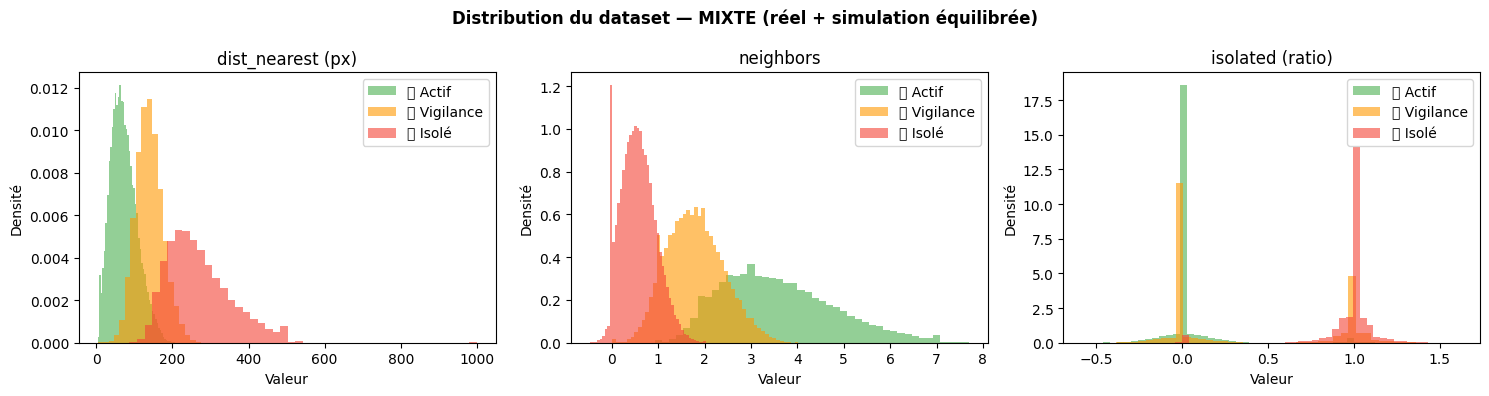

Distribution visualisée.


In [7]:
# Normalisation StandardScaler (fit sur les données d'entraînement)
scaler_visual = StandardScaler()
X_flat = X_combined.reshape(-1, 3)
scaler_visual.fit(X_flat)
X_scaled = scaler_visual.transform(X_flat).reshape(X_combined.shape)
y_final  = y_combined.astype(int)

print(f"Dataset normalisé : {X_scaled.shape}")
print(f"Moyenne features  : {X_flat.mean(axis=0).round(2)}")
print(f"Std features      : {X_flat.std(axis=0).round(2)}")

# Visualisation distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Distribution du dataset — {data_source}', fontsize=12, fontweight='bold')

class_names  = ['🟢 Actif', '🟡 Vigilance', '🔴 Isolé']
class_colors = ['#4CAF50', '#FF9800', '#F44336']
feature_names = ['dist_nearest (px)', 'neighbors', 'isolated (ratio)']

for feat_idx, (ax, feat_name) in enumerate(zip(axes, feature_names)):
    for cls_idx, (name, color) in enumerate(zip(class_names, class_colors)):
        mask = y_final == cls_idx
        data = X_combined[mask, :, feat_idx].flatten()
        ax.hist(data, bins=50, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(feat_name)
    ax.set_xlabel('Valeur')
    ax.set_ylabel('Densité')
    ax.legend()

plt.tight_layout()
plt.savefig('dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Distribution visualisée.")

In [8]:
class IsolationDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]


class VisualIsolationLSTM(nn.Module):
    """LSTM bidirectionnel + Attention pour classification 3 classes."""
    def __init__(self, input_size=3, hidden_size=32, num_layers=2, dropout=0.4, num_classes=3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout, bidirectional=True)
        self.bn1      = nn.BatchNorm1d(hidden_size * 2)
        self.dropout1 = nn.Dropout(dropout)

        # Mécanisme d'attention
        self.attention = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )

        # Classificateur profond
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(dropout),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(dropout * 0.8),
            nn.Linear(16, num_classes)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out    = self.bn1(out.transpose(1, 2)).transpose(1, 2)
        # Attention
        attn_weights = torch.softmax(self.attention(out), dim=1)
        context      = (attn_weights * out).sum(dim=1)
        context      = self.dropout1(context)
        return self.classifier(context)


# Split stratifié 70/15/15
X_tr, X_te, y_tr, y_te = train_test_split(X_scaled, y_final,
                                            test_size=0.15, random_state=42, stratify=y_final)
X_tr, X_va, y_tr, y_va = train_test_split(X_tr, y_tr,
                                            test_size=0.15, random_state=42, stratify=y_tr)

train_loader = DataLoader(IsolationDataset(X_tr, y_tr), batch_size=64, shuffle=True,  drop_last=True)
val_loader   = DataLoader(IsolationDataset(X_va, y_va), batch_size=64, shuffle=False)
test_loader  = DataLoader(IsolationDataset(X_te, y_te), batch_size=64, shuffle=False)

model_visual = VisualIsolationLSTM(input_size=3, num_classes=3).to(DEVICE)
print(model_visual)
print(f'\nParamètres : {sum(p.numel() for p in model_visual.parameters()):,}')
print(f'Train: {len(X_tr)} | Val: {len(X_va)} | Test: {len(X_te)}')
print(f'Classes train : {np.bincount(y_tr)}')
print(f'Classes val   : {np.bincount(y_va)}')
print(f'Classes test  : {np.bincount(y_te)}')

VisualIsolationLSTM(
  (lstm): LSTM(3, 32, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.4, inplace=False)
  (attention): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.32000000000000006, inplace=False)
    (7): Linear(in_features=16, out_features=3, bias=True)
  )
)

Paramètres : 39,524
Train: 7947 | Val: 1403 | Test: 1650
Classes train : [2670 2642 2635]
Classes val   : [471 467 465]
Classes test  : [554 549 547]


## 9. Entraînement — Label Smoothing + CosineAnnealing + EarlyStopping

Stratégies anti-overfitting :
- **Label Smoothing** (ε=0.1) pour réduire la sur-confiance
- **CosineAnnealingLR** pour un LR cyclique sans divergence
- **EarlyStopping** (patience=15) avec sauvegarde du meilleur modèle
- **Gradient clipping** (max_norm=1.0)

In [9]:
class LabelSmoothingCE(nn.Module):
    """CrossEntropy avec label smoothing pour réduire la sur-confiance."""
    def __init__(self, smoothing=0.1, num_classes=3):
        super().__init__()
        self.smoothing   = smoothing
        self.num_classes = num_classes

    def forward(self, preds, targets):
        log_probs = torch.log_softmax(preds, dim=-1)
        # Cibles lissées
        smooth_targets = torch.full_like(log_probs, self.smoothing / (self.num_classes - 1))
        smooth_targets.scatter_(1, targets.unsqueeze(1), 1 - self.smoothing)
        return -(smooth_targets * log_probs).sum(dim=-1).mean()


class EarlyStopping:
    def __init__(self, patience=15, min_delta=0.001):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_loss  = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter   = 0


criterion     = LabelSmoothingCE(smoothing=0.1, num_classes=3)
optimizer     = optim.Adam(model_visual.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler     = CosineAnnealingLR(optimizer, T_max=60, eta_min=1e-5)
early_stopping = EarlyStopping(patience=15)

num_epochs = 100
history    = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}
best_val_acc = 0

print("Début de l'entraînement...")
print("-" * 65)
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Val Loss':>8} | {'Train Acc':>9} | {'Val Acc':>8} | {'F1':>6}")
print("-" * 65)

for epoch in range(num_epochs):
    # ── Training ──
    model_visual.train()
    train_loss = train_correct = 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        outputs = model_visual(Xb)
        loss    = criterion(outputs, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_visual.parameters(), 1.0)
        optimizer.step()
        train_loss    += loss.item()
        train_correct += (outputs.argmax(1) == yb).sum().item()

    # ── Validation ──
    model_visual.eval()
    val_loss = val_correct = 0
    val_preds, val_true = [], []
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            outputs   = model_visual(Xb)
            val_loss += criterion(outputs, yb).item()
            preds     = outputs.argmax(1)
            val_correct += (preds == yb).sum().item()
            val_preds.extend(preds.cpu().numpy())
            val_true.extend(yb.cpu().numpy())

    train_acc = train_correct / len(train_loader.dataset)
    val_acc   = val_correct   / len(val_loader.dataset)
    val_f1    = f1_score(val_true, val_preds, average='weighted')
    tl        = train_loss / len(train_loader)
    vl        = val_loss   / len(val_loader)

    history['train_loss'].append(tl)
    history['val_loss'].append(vl)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    scheduler.step()

    if (epoch + 1) % 10 == 0 or val_acc > best_val_acc:
        print(f"{epoch+1:>6} | {tl:>10.4f} | {vl:>8.4f} | {train_acc:>9.4f} | {val_acc:>8.4f} | {val_f1:>6.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model_visual.state_dict(), 'best_visual_model.pt')

    early_stopping(vl)
    if early_stopping.early_stop:
        print(f"\n  Early stopping à l'epoch {epoch+1}")
        break

print("-" * 65)
print(f" Entraînement terminé! Meilleure val_acc: {best_val_acc:.4f}")
model_visual.load_state_dict(torch.load('best_visual_model.pt', map_location=DEVICE))
print("Meilleur modèle chargé.")

Début de l'entraînement...
-----------------------------------------------------------------
 Epoch | Train Loss | Val Loss | Train Acc |  Val Acc |     F1
-----------------------------------------------------------------
     1 |     0.7575 |   0.5449 |    0.7569 |   0.9081 | 0.9081
     2 |     0.6271 |   0.5273 |    0.8708 |   0.9159 | 0.9165
     6 |     0.5983 |   0.5218 |    0.8821 |   0.9202 | 0.9204
     9 |     0.5966 |   0.5210 |    0.8844 |   0.9216 | 0.9222
    10 |     0.5961 |   0.5264 |    0.8871 |   0.9173 | 0.9176
    20 |     0.5842 |   0.5191 |    0.8933 |   0.9216 | 0.9218

  Early stopping à l'epoch 23
-----------------------------------------------------------------
 Entraînement terminé! Meilleure val_acc: 0.9216
Meilleur modèle chargé.


## 10. Courbes d'apprentissage et Évaluation

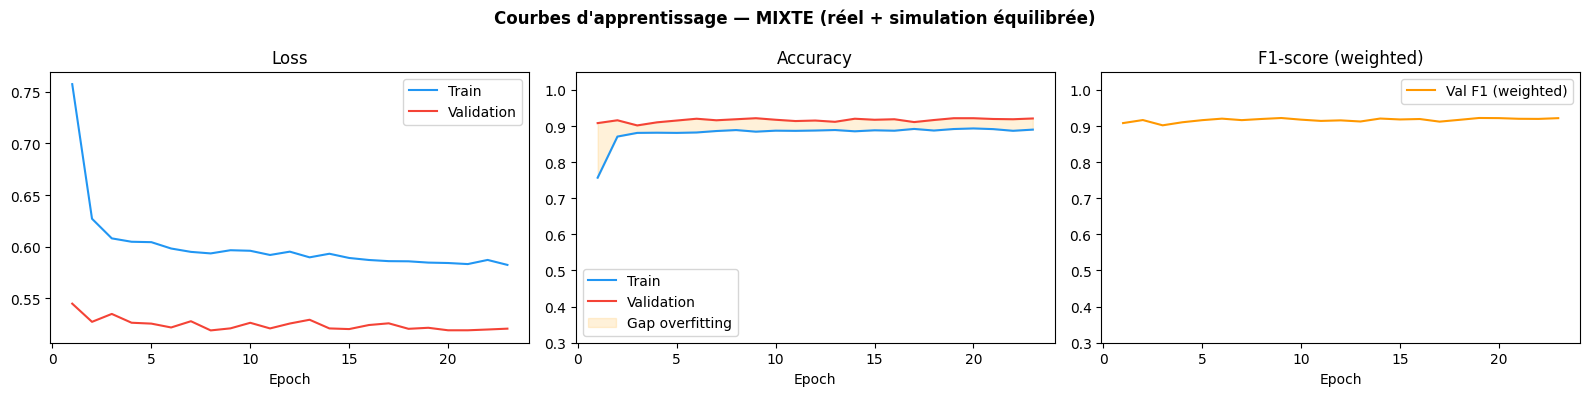

=== Rapport de classification — MIXTE (réel + simulation équilibrée) ===
              precision    recall  f1-score   support

       Actif       0.90      0.89      0.89       554
   Vigilance       0.86      0.87      0.86       549
       Isolé       0.97      0.96      0.97       547

    accuracy                           0.91      1650
   macro avg       0.91      0.91      0.91      1650
weighted avg       0.91      0.91      0.91      1650



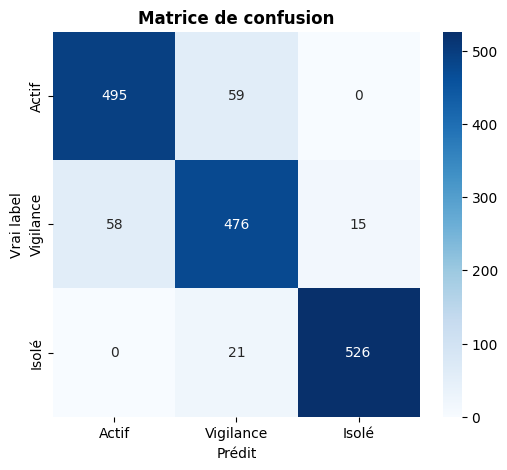

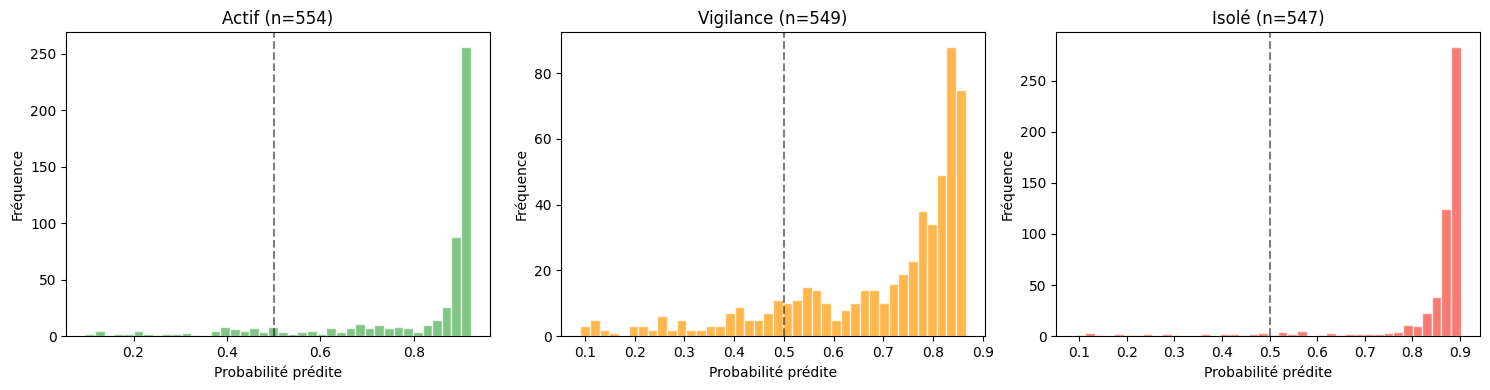

In [10]:
# Courbes d'apprentissage (3 panels : Loss, Accuracy, F1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f"Courbes d'apprentissage — {data_source}", fontsize=12, fontweight='bold')
ep = range(1, len(history['train_loss']) + 1)

axes[0].plot(ep, history['train_loss'], label='Train',      color='#2196F3')
axes[0].plot(ep, history['val_loss'],   label='Validation', color='#F44336')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(ep, history['train_acc'], label='Train',      color='#2196F3')
axes[1].plot(ep, history['val_acc'],   label='Validation', color='#F44336')
axes[1].fill_between(ep, history['train_acc'], history['val_acc'],
                     alpha=0.15, color='orange', label='Gap overfitting')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0.3, 1.05); axes[1].legend()

axes[2].plot(ep, history['val_f1'], label='Val F1 (weighted)', color='#FF9800')
axes[2].set_title('F1-score (weighted)'); axes[2].set_xlabel('Epoch')
axes[2].set_ylim(0.3, 1.05); axes[2].legend()

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Évaluation sur le set de test ──
model_visual.eval()
all_preds, all_true, all_probs = [], [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        outputs = model_visual(Xb.to(DEVICE))
        probs   = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(np.argmax(probs, axis=1))
        all_true.extend(yb.numpy())

print(f'=== Rapport de classification — {data_source} ===')
print(classification_report(all_true, all_preds,
                            target_names=['Actif', 'Vigilance', 'Isolé'],
                            labels=[0, 1, 2], zero_division=0))

# Matrice de confusion
cm = confusion_matrix(all_true, all_preds, labels=[0, 1, 2])
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Actif', 'Vigilance', 'Isolé'],
            yticklabels=['Actif', 'Vigilance', 'Isolé'], ax=axes[0])
axes[0].set_title('Matrice de confusion', fontweight='bold')
axes[0].set_ylabel('Vrai label'); axes[0].set_xlabel('Prédit')

# Distribution des probabilités par classe
class_names_short = ['Actif', 'Vigilance', 'Isolé']
class_colors      = ['#4CAF50', '#FF9800', '#F44336']
axes[1].set_visible(False)
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))
for i, (name, color) in enumerate(zip(class_names_short, class_colors)):
    mask = np.array(all_true) == i
    if mask.sum() > 0:
        probs_class = [p[i] for p, m in zip(all_probs, mask) if m]
        axes2[i].hist(probs_class, bins=40, alpha=0.7, color=color, edgecolor='white')
        axes2[i].axvline(x=0.5, color='black', linestyle='--', alpha=0.5)
        axes2[i].set_title(f'{name} (n={mask.sum()})')
    else:
        axes2[i].text(0.5, 0.5, 'Aucune donnée', ha='center', va='center', transform=axes2[i].transAxes)
    axes2[i].set_xlabel('Probabilité prédite'); axes2[i].set_ylabel('Fréquence')

plt.tight_layout()
plt.savefig('proba_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

fig.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Test sur les Vidéos (DeepSORT + LSTM)

In [11]:
video_paths = [
    '/kaggle/input/datasets/sarrabenothmane/videooos/isolation.mp4',
    '/kaggle/input/datasets/sarrabenothmane/videooos/vid.avi',
    '/kaggle/input/datasets/sarrabenothmane/videooos/video.avi',
    '/kaggle/input/datasets/sarrabenothmane/videooos/v.avi'
]


def analyze_video_deepsort(video_path, yolo_model, window_size=WINDOW_SIZE):
    """Analyse une vidéo et retourne les historiques de tracks."""
    print(f"\n{'='*60}")
    print(f"Analyse: {video_path.split('/')[-1]}")
    print(f"{'='*60}")
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f" Impossible d'ouvrir {video_path}")
        return {}

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps          = cap.get(cv2.CAP_PROP_FPS)
    print(f" {total_frames} frames | {fps:.1f} FPS")

    tracker         = init_tracker()
    track_histories = {}
    frame_count     = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if frame_count % 5 == 0:
            features_by_id = detect_and_track(frame, yolo_model, tracker)
            for tid, feat in features_by_id.items():
                if tid not in track_histories:
                    track_histories[tid] = []
                track_histories[tid].append(feat)
        frame_count += 1
    cap.release()

    n_valid = sum(1 for h in track_histories.values() if len(h) >= window_size)
    n_short = sum(1 for h in track_histories.values() if len(h) < window_size)
    print(f" {frame_count} frames | {len(track_histories)} IDs | {n_valid} analysés | {n_short} ignorés")
    return track_histories


def compute_scores_deepsort(track_histories, model, scaler, window_size=WINDOW_SIZE):
    """Prédit la classe d'isolement pour chaque track."""
    model.eval()
    results = {}
    with torch.no_grad():
        for tid, feat_list in sorted(track_histories.items(), key=lambda x: str(x[0])):
            if len(feat_list) < window_size:
                continue
            seq_raw    = np.array([[f['dist_nearest'], f['neighbors'], f['isolated']]
                                   for f in feat_list[-window_size:]], dtype=np.float32)
            seq_scaled = scaler.transform(seq_raw)
            seq_tensor = torch.FloatTensor(seq_scaled).unsqueeze(0).to(DEVICE)
            probs      = torch.softmax(model(seq_tensor), dim=1).cpu().numpy()[0]
            pred_class = int(np.argmax(probs))
            score      = round(probs[pred_class] * 100, 1)

            status_icons = {0: '🟢 OK (actif)', 1: '🟡 Vigilance', 2: '🔴 ALERTE (isolé)'}
            results[tid] = {
                'name':           f'Résident_ID{str(tid)}',
                'score':          score,
                'status':         status_icons[pred_class],
                'pred_class':     pred_class,
                'probs':          probs,
                'avg_dist':       round(np.mean([f['dist_nearest'] for f in feat_list]), 1),
                'avg_neighbors':  round(np.mean([f['neighbors']    for f in feat_list]), 1),
                'isolated_ratio': round(np.mean([f['isolated']     for f in feat_list]) * 100, 1),
                'n_frames':       len(feat_list)
            }
            icon = ['🟢','🟡','🔴'][pred_class]
            print(f"  Track {str(tid):>5} → {score:5.1f}% {icon} | "
                  f"dist={results[tid]['avg_dist']}px, "
                  f"voisins={results[tid]['avg_neighbors']}, "
                  f"seul={results[tid]['isolated_ratio']}%, "
                  f"{len(feat_list)} frames")
    return results


all_results = {}
for video_path in video_paths:
    video_name      = video_path.split('/')[-1]
    track_histories = analyze_video_deepsort(video_path, yolo_model)
    if not track_histories:
        all_results[video_name] = {}
        continue
    print("\n Scores d'isolement:")
    scores = compute_scores_deepsort(track_histories, model_visual, scaler_visual)
    all_results[video_name] = scores

print("\n Analyse terminée!")


Analyse: isolation.mp4
 145 frames | 24.0 FPS
 145 frames | 10 IDs | 6 analysés | 4 ignorés

 Scores d'isolement:
  Track     1 →  70.8% 🟡 | dist=127.9px, voisins=1.4, seul=22.2%, 27 frames
  Track     2 →  75.3% 🟢 | dist=112.9px, voisins=2.1, seul=7.4%, 27 frames
  Track     3 →  54.0% 🔴 | dist=138.1px, voisins=0.4, seul=55.6%, 27 frames
  Track     4 →  47.9% 🟢 | dist=85.3px, voisins=1.9, seul=0.0%, 27 frames
  Track     5 →  56.9% 🟢 | dist=79.9px, voisins=1.9, seul=0.0%, 27 frames
  Track     8 →  89.8% 🟢 | dist=78.9px, voisins=3.7, seul=0.0%, 25 frames

Analyse: vid.avi
 396 frames | 30.0 FPS
 396 frames | 5 IDs | 5 analysés | 0 ignorés

 Scores d'isolement:
  Track     1 →  85.8% 🔴 | dist=173.4px, voisins=0.4, seul=62.8%, 78 frames
  Track     2 →  73.1% 🟡 | dist=145.9px, voisins=0.6, seul=39.7%, 78 frames
  Track     4 →  85.9% 🔴 | dist=131.7px, voisins=0.9, seul=25.4%, 59 frames
  Track     5 →  84.1% 🟡 | dist=108.8px, voisins=1.1, seul=5.7%, 70 frames
  Track     6 →  73.4% 🟡 

## 12. Dashboard Visuel par Vidéo

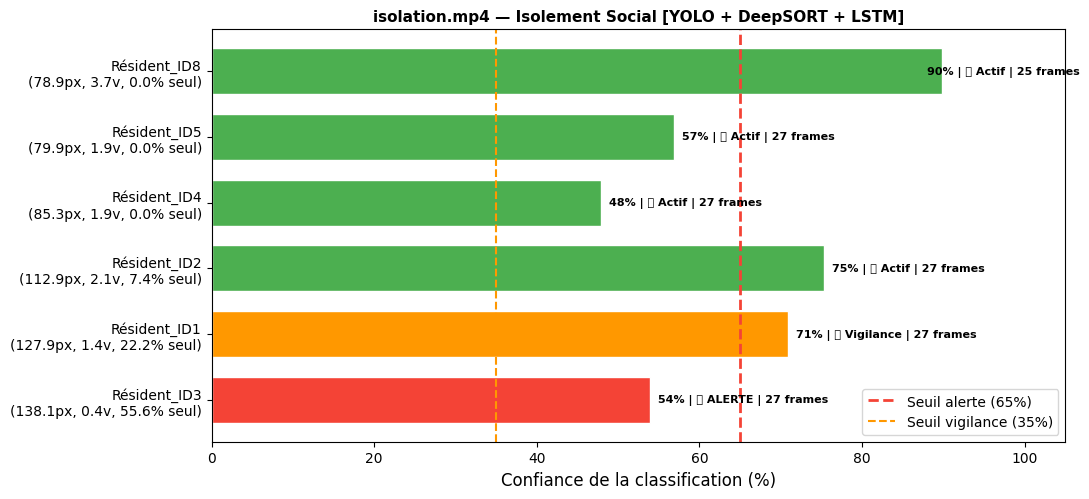

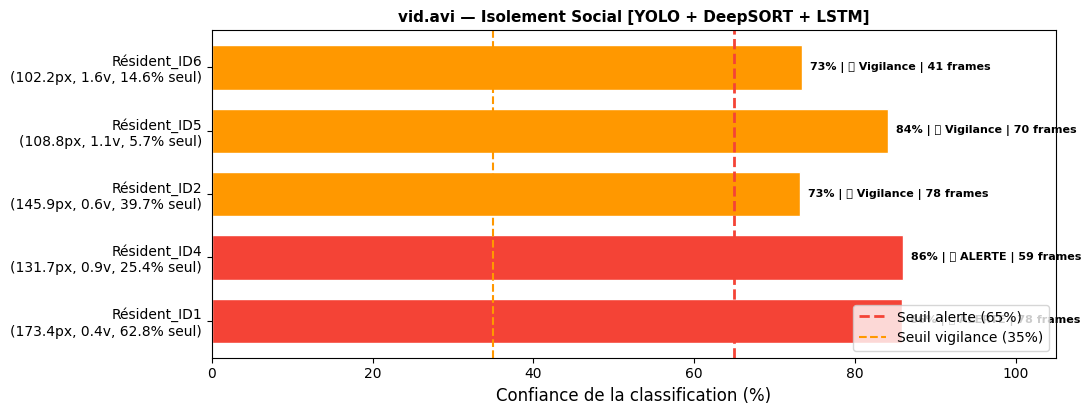

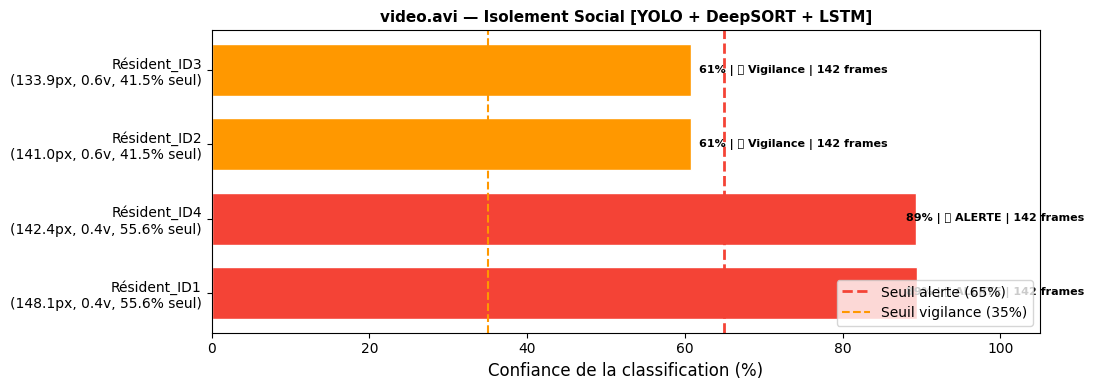

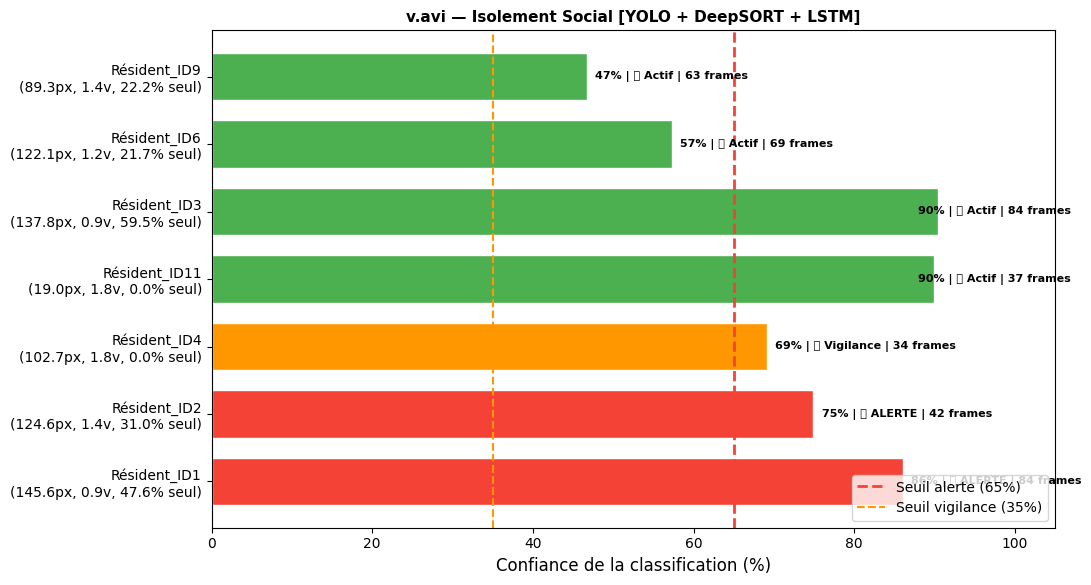

In [12]:
for video_name, scores in all_results.items():
    if not scores:
        print(f"\n  {video_name}: aucun résident analysé")
        continue

    fig, ax = plt.subplots(figsize=(11, max(4, len(scores) * 0.85)))

    # Tri par classe (isolés en haut)
    sorted_items = sorted(scores.items(), key=lambda x: x[1]['pred_class'], reverse=True)
    names  = [f"{d['name']}\n({d['avg_dist']}px, {d['avg_neighbors']}v, {d['isolated_ratio']}% seul)"
              for _, d in sorted_items]
    vals   = [d['probs'][d['pred_class']] * 100 for _, d in sorted_items]
    colors = ['#F44336' if d['pred_class'] == 2 else '#FF9800' if d['pred_class'] == 1 else '#4CAF50'
              for _, d in sorted_items]

    bars = ax.barh(names, vals, color=colors, edgecolor='white', height=0.7)

    # Lignes de seuil
    ax.axvline(x=65, color='#F44336', linestyle='--', linewidth=2,   label='Seuil alerte (65%)')
    ax.axvline(x=35, color='#FF9800', linestyle='--', linewidth=1.5, label='Seuil vigilance (35%)')
    ax.set_xlim(0, 105)
    ax.set_xlabel("Confiance de la classification (%)", fontsize=12)
    ax.set_title(f'{video_name} — Isolement Social [YOLO + DeepSORT + LSTM]',
                 fontsize=11, fontweight='bold')
    ax.legend(loc='lower right')

    for bar, val, (_, d) in zip(bars, vals, sorted_items):
        status = ['🟢 Actif', '🟡 Vigilance', '🔴 ALERTE'][d['pred_class']]
        txt = f"{val:.0f}% | {status} | {d['n_frames']} frames"
        ax.text(min(bar.get_width() + 1, 88),
                bar.get_y() + bar.get_height() / 2,
                txt, va='center', fontsize=8, fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'dashboard_{video_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 13. Rapport Final Consolidé

In [13]:
def generate_report(all_results, data_source):
    now    = datetime.now().strftime('%d/%m/%Y %H:%M')
    report = "=" * 70 + "\n"
    report += f"  RAPPORT ISOLEMENT SOCIAL — {now}\n"
    report += f"  Source entraînement : {data_source}\n"
    report += "=" * 70 + "\n"
    tot_alerte = tot_vig = tot_ok = 0

    for video_name, scores in all_results.items():
        report += f"\n {video_name}\n" + "-" * 50 + "\n"
        if not scores:
            report += "  Aucun résident détecté\n"
            continue

        alertes   = [d for d in scores.values() if d['pred_class'] == 2]
        vigilance = [d for d in scores.values() if d['pred_class'] == 1]
        ok        = [d for d in scores.values() if d['pred_class'] == 0]
        tot_alerte += len(alertes)
        tot_vig    += len(vigilance)
        tot_ok     += len(ok)

        if alertes:
            report += "  🔴 ALERTES CRITIQUES (isolés):\n"
            for d in alertes:
                report += (f"     !! {d['name']}: {d['score']}% conf | "
                           f"Dist: {d['avg_dist']}px | Voisins: {d['avg_neighbors']} | "
                           f"Seul: {d['isolated_ratio']}% | {d['n_frames']} frames\n")
        if vigilance:
            report += "  🟡 VIGILANCE:\n"
            for d in vigilance:
                report += (f"     >> {d['name']}: {d['score']}% conf | "
                           f"Dist: {d['avg_dist']}px | Voisins: {d['avg_neighbors']} | "
                           f"Seul: {d['isolated_ratio']}%\n")
        if ok:
            report += "  🟢 OK (actifs):\n"
            for d in ok:
                report += f"     OK {d['name']}: {d['score']}% conf | {d['n_frames']} frames\n"

    report += "\n" + "=" * 70 + "\n"
    report += f"  BILAN GLOBAL : {tot_alerte} alertes 🔴 | {tot_vig} vigilance 🟡 | {tot_ok} OK 🟢\n"
    report += "=" * 70
    return report


print(generate_report(all_results, data_source))

with open('rapport_isolement.txt', 'w', encoding='utf-8') as f:
    f.write(generate_report(all_results, data_source))


  RAPPORT ISOLEMENT SOCIAL — 31/03/2026 18:56
  Source entraînement : MIXTE (réel + simulation équilibrée)

 isolation.mp4
--------------------------------------------------
  🔴 ALERTES CRITIQUES (isolés):
     !! Résident_ID3: 54.0% conf | Dist: 138.1px | Voisins: 0.4 | Seul: 55.6% | 27 frames
  🟡 VIGILANCE:
     >> Résident_ID1: 70.80000305175781% conf | Dist: 127.9px | Voisins: 1.4 | Seul: 22.2%
  🟢 OK (actifs):
     OK Résident_ID2: 75.30000305175781% conf | 27 frames
     OK Résident_ID4: 47.900001525878906% conf | 27 frames
     OK Résident_ID5: 56.900001525878906% conf | 27 frames
     OK Résident_ID8: 89.80000305175781% conf | 25 frames

 vid.avi
--------------------------------------------------
  🔴 ALERTES CRITIQUES (isolés):
     !! Résident_ID1: 85.80000305175781% conf | Dist: 173.4px | Voisins: 0.4 | Seul: 62.8% | 78 frames
     !! Résident_ID4: 85.9000015258789% conf | Dist: 131.7px | Voisins: 0.9 | Seul: 25.4% | 59 frames
  🟡 VIGILANCE:
     >> Résident_ID2: 73.099998474